In [1]:
# optimizing functions of one variable
# cost minimization

# to make the best possible investment

# construct a target function
# evaluate its minimum

In [3]:
# product p
# A, B

# consistent with the 12 months period


# w is the percentage
# n is supplied per month as n (units) 
from jax import grad
import jax.numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

In [4]:
import w1_unittest

In [6]:
df = pd.read_csv("prices.csv")
print(df)

         date  price_supplier_a_dollars_per_item  \
0   1/02/2016                                104   
1   1/03/2016                                108   
2   1/04/2016                                101   
3   1/05/2016                                104   
4   1/06/2016                                102   
5   1/07/2016                                105   
6   1/08/2016                                114   
7   1/09/2016                                102   
8   1/10/2016                                105   
9   1/11/2016                                101   
10  1/12/2016                                109   
11  1/01/2017                                103   
12  1/02/2017                                 93   
13  1/03/2017                                 98   
14  1/04/2017                                 92   
15  1/05/2017                                 97   
16  1/06/2017                                 96   
17  1/07/2017                                 94   
18  1/08/201

In [7]:
print(df.columns)

Index(['date', 'price_supplier_a_dollars_per_item',
       'price_supplier_b_dollars_per_item'],
      dtype='object')


### Exercise 1

In [8]:
prices_A = df.price_supplier_a_dollars_per_item
prices_B = df.price_supplier_b_dollars_per_item
prices_A = np.array(prices_A).astype("float32")
prices_B = np.array(prices_B).astype("float32")

In [9]:
print("Some prices of supplier A:", prices_A[0:5])
print("Some prices of supplier B:", prices_B[0:5])
print("Average of the prices, supplier A:", np.mean(prices_A))
print("Average of the prices, supplier B:", np.mean(prices_B))

Some prices of supplier A: [104. 108. 101. 104. 102.]
Some prices of supplier B: [76. 76. 84. 79. 81.]
Average of the prices, supplier A: 100.799995
Average of the prices, supplier B: 100.0


In [10]:
w1_unittest.test_load_and_convert_data(prices_A, prices_B)

 All tests passed


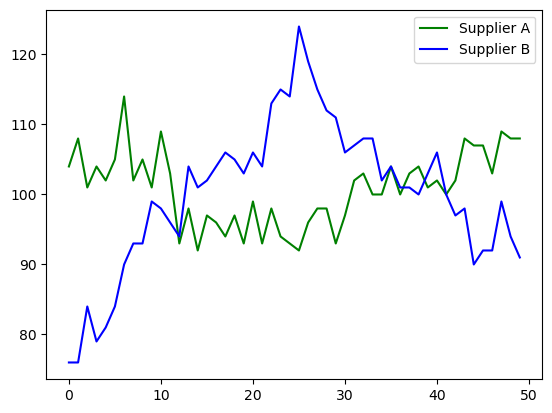

In [11]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
plt.plot(prices_A, 'g', label="Supplier A")
plt.plot(prices_B, 'b', label="Supplier B")
plt.legend()

plt.show()

In [12]:
# construct loss function
# find its minimum point
# risk management theory

# f(w)
def f_of_omega(omega):
    f = prices_A * omega + prices_B * (1-omega)
    return f

In [18]:
def L_of_omega(omega):
    return 1/len(f_of_omega(omega)) * np.sum((f_of_omega(omega) - np.mean(f_of_omega(omega)))**2)

In [19]:
print("L(omega = 0) =",L_of_omega(0))
print("L(omega = 0.2) =",L_of_omega(0.2))
print("L(omega = 0.8) =",L_of_omega(0.8))
print("L(omega = 1) =",L_of_omega(1))

L(omega = 0) = 110.72
L(omega = 0.2) = 61.156796
L(omega = 0.8) = 11.212797
L(omega = 1) = 27.48


In [20]:
w1_unittest.test_f_of_omega(f_of_omega)

 All tests passed


In [22]:
N = 1001
omega_array = np.linspace(0, 1, N, endpoint=True)

def L_of_omega_array(omega_array):
    N = len(omega_array)
    L_array = np.zeros(N)
    
    for i in range(N):
        L = L_of_omega(omega_array[i])
        L_array = L_array.at[i].set(L)
    
    return L_array

L_array = L_of_omega_array(omega_array)

In [23]:
print("L(omega = 0) =",L_array[0])
print("L(omega = 1) =",L_array[N-1])

L(omega = 0) = 110.72
L(omega = 1) = 27.48


In [24]:
i_opt = L_array.argmin()
omega_opt = omega_array[i_opt]
L_opt = L_array[i_opt]
print(f'omega_min = {omega_opt:.3f}\nL_of_omega_min = {L_opt:.7f}')

omega_min = 0.702
L_of_omega_min = 9.2497196


In [25]:
# machine learning have hundres of paramerers
# calculus comes into play

def dLdOmega_of_omega_array(omega_array):
    N = len(omega_array)
    dLdOmega_array = np.zeros(N)

    for i in range(N):
        ### START CODE HERE ### (~ 2 lines of code)
        dLdOmega = grad(L_of_omega)(omega_array[i])
        dLdOmega_array = dLdOmega_array.at[i].set(dLdOmega)
        ### END CODE HERE ###
        
    return dLdOmega_array

dLdOmega_array = dLdOmega_of_omega_array(omega_array)

In [29]:
print("dLdOmega(omega = 0) =",dLdOmega_array[0])
print("dLdOmega(omega = 1) =",dLdOmega_array[N-1])

dLdOmega(omega = 0) = -288.95984
dLdOmega(omega = 1) = 122.48001


In [28]:
w1_unittest.test_dLdOmega_of_omega_array(dLdOmega_of_omega_array)

Test case "default_check". Wrong output of dLdOmega_of_omega_array for omega_array = 
[0.        0.001     0.002     ... 0.998     0.9990001 1.       ]
Test for index i = 0. 
	Expected: 
-288.96
	Got: 
-288.9598388671875
Test case "default_check". Wrong output of dLdOmega_of_omega_array for omega_array = 
[0.        0.001     0.002     ... 0.998     0.9990001 1.       ]
Test for index i = 1000. 
	Expected: 
122.47999
	Got: 
122.48001098632812
Test case "default_check". Wrong output of dLdOmega_of_omega_array for omega_array = 
[0.        0.001     0.002     ... 0.998     0.9990001 1.       ]
Test for index i = 400. 
	Expected: 
-124.38398
	Got: 
-124.38396453857422
Test case "extra_check". Wrong output of dLdOmega_of_omega_array for omega_array = 
[0.         0.1        0.2        0.3        0.4        0.5
 0.6        0.7        0.8        0.90000004 1.        ]
Test for index i = 0. 
	Expected: 
-288.96
	Got: 
-288.9598388671875
Test case "extra_check". Wrong output of dLdOmega_of_ome

In [30]:
i_opt_2 = np.abs(dLdOmega_array).argmin()
omega_opt_2 = omega_array[i_opt_2]
dLdOmega_opt_2 = dLdOmega_array[i_opt_2]
print(f'omega_min = {omega_opt_2:.3f}\ndLdOmega_min = {dLdOmega_opt_2:.7f}')

omega_min = 0.702
dLdOmega_min = -0.1291218
